# 进一步优化：正则化线性模型对比

`03_submission_improve_from_baseline.csv` 的 Kaggle 公榜分数达到 `0.12629`，说明“移除明显异常点 + 偏态数值特征 log1p”是有效方向。

本 notebook 在这个有效数据处理方案上继续优化模型：比较 Ridge、Lasso、ElasticNet 以及简单融合，生成新的提交文件。

## 1. 导入依赖与读取数据

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNetCV, LassoCV, RidgeCV
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

pd.set_option("display.max_columns", 120)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "data"
SUBMISSION_DIR = ROOT / "submissions"

train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")

train.shape, test.shape

((1460, 81), (1459, 80))

## 2. 使用上一轮有效的数据处理方案

保留上一轮已经被 Kaggle 公榜验证有效的两个改动：

- 移除训练集中 `GrLivArea > 4000` 且 `SalePrice < 300000` 的明显异常点。
- 对偏态大于 `0.75` 且非负的数值特征做 `log1p` 变换。

这一步不新增复杂特征，避免再次引入不可控噪声。

In [2]:
target = "SalePrice"
id_column = "Id"

outlier_mask = (train["GrLivArea"] > 4000) & (train["SalePrice"] < 300000)
train_model = train.loc[~outlier_mask].copy()

X = train_model.drop(columns=[target, id_column])
y = train_model[target]
X_test = test.drop(columns=[id_column]).copy()
test_ids = test[id_column]

print("移除异常点数量:", int(outlier_mask.sum()))
print("异常点 Id:", train.loc[outlier_mask, id_column].tolist())
X.shape, X_test.shape

移除异常点数量: 2
异常点 Id: [524, 1299]


((1458, 79), (1459, 79))

In [3]:
def log_transform_skewed_features(X_train: pd.DataFrame, X_test: pd.DataFrame, threshold: float = 0.75):
    X_train = X_train.copy()
    X_test = X_test.copy()

    numeric_columns = X_train.select_dtypes(include="number").columns
    skewness = X_train[numeric_columns].skew().sort_values(ascending=False)
    skewed_columns = skewness[skewness > threshold].index.tolist()

    transformed_columns = []
    for column in skewed_columns:
        min_value = min(X_train[column].min(), X_test[column].min())
        if pd.notna(min_value) and min_value >= 0:
            X_train[column] = np.log1p(X_train[column])
            X_test[column] = np.log1p(X_test[column])
            transformed_columns.append(column)

    return X_train, X_test, transformed_columns


X_log, X_test_log, transformed_columns = log_transform_skewed_features(X, X_test)
print("log1p 处理的列数量:", len(transformed_columns))
transformed_columns

log1p 处理的列数量: 20


['MiscVal',
 'PoolArea',
 'LotArea',
 '3SsnPorch',
 'LowQualFinSF',
 'KitchenAbvGr',
 'BsmtFinSF2',
 'ScreenPorch',
 'BsmtHalfBath',
 'EnclosedPorch',
 'MasVnrArea',
 'OpenPorchSF',
 'WoodDeckSF',
 'LotFrontage',
 'MSSubClass',
 'GrLivArea',
 'BsmtUnfSF',
 '1stFlrSF',
 '2ndFlrSF',
 'BsmtFinSF1']

## 3. 公共建模函数

In [4]:
def make_one_hot_encoder() -> OneHotEncoder:
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_model(base_model, scaler="standard") -> TransformedTargetRegressor:
    numeric_features = X_log.select_dtypes(include="number").columns.tolist()
    categorical_features = X_log.select_dtypes(exclude="number").columns.tolist()
    scaler_step = RobustScaler() if scaler == "robust" else StandardScaler()

    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", scaler_step),
        ]
    )
    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", make_one_hot_encoder()),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_features),
            ("cat", categorical_pipeline, categorical_features),
        ]
    )

    regressor = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", base_model),
        ]
    )

    return TransformedTargetRegressor(
        regressor=regressor,
        func=np.log1p,
        inverse_func=np.expm1,
    )


def rmsle(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_pred = np.maximum(y_pred, 0)
    return float(np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(y_pred))))


def cross_validate_single_model(model, X_data: pd.DataFrame, y_data: pd.Series) -> float:
    scores = []
    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    for train_idx, valid_idx in cv.split(X_data):
        fold_model = clone(model)
        fold_model.fit(X_data.iloc[train_idx], y_data.iloc[train_idx])
        predictions = fold_model.predict(X_data.iloc[valid_idx])
        scores.append(rmsle(y_data.iloc[valid_idx], predictions))

    return float(np.mean(scores))


def cross_validate_ensemble(models: dict[str, TransformedTargetRegressor], X_data: pd.DataFrame, y_data: pd.Series) -> float:
    scores = []
    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    for train_idx, valid_idx in cv.split(X_data):
        fold_predictions = []
        for model in models.values():
            fold_model = clone(model)
            fold_model.fit(X_data.iloc[train_idx], y_data.iloc[train_idx])
            fold_predictions.append(fold_model.predict(X_data.iloc[valid_idx]))

        blended_predictions = np.mean(fold_predictions, axis=0)
        scores.append(rmsle(y_data.iloc[valid_idx], blended_predictions))

    return float(np.mean(scores))

## 4. 单模型对比

Lasso 和 ElasticNet 能在高维 one-hot 特征中做一定特征选择，可能比 Ridge 更适合当前处理后的数据。

In [5]:
models = {
    "ridge_standard": build_model(RidgeCV(alphas=np.logspace(-3, 3, 13)), scaler="standard"),
    "ridge_robust": build_model(RidgeCV(alphas=np.logspace(-3, 3, 13)), scaler="robust"),
    "lasso": build_model(
        LassoCV(alphas=np.logspace(-4, 0, 40), cv=5, max_iter=30000, random_state=42),
        scaler="standard",
    ),
    "elasticnet": build_model(
        ElasticNetCV(
            l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0],
            alphas=np.logspace(-4, 0, 40),
            cv=5,
            max_iter=30000,
            random_state=42,
        ),
        scaler="standard",
    ),
}

single_scores = []
for name, model in models.items():
    score = cross_validate_single_model(model, X_log, y)
    single_scores.append({"方案": name, "CV_RMSLE": score})

single_score_table = pd.DataFrame(single_scores).sort_values("CV_RMSLE")
single_score_table

,方案,CV_RMSLE
2,lasso,0.109897
3,elasticnet,0.110014
1,ridge_robust,0.112403
0,ridge_standard,0.112474


## 5. 简单融合对比

融合不一定比最好的单模型强，但可以降低不同模型的偶然误差。这里先只测试少量组合，避免过拟合本地 CV。

In [6]:
ensemble_candidates = {
    "blend_ridge_lasso": {"ridge_standard": models["ridge_standard"], "lasso": models["lasso"]},
    "blend_ridge_elasticnet": {"ridge_standard": models["ridge_standard"], "elasticnet": models["elasticnet"]},
    "blend_ridge_lasso_elasticnet": {
        "ridge_standard": models["ridge_standard"],
        "lasso": models["lasso"],
        "elasticnet": models["elasticnet"],
    },
}

ensemble_scores = []
for name, model_group in ensemble_candidates.items():
    score = cross_validate_ensemble(model_group, X_log, y)
    ensemble_scores.append({"方案": name, "CV_RMSLE": score})

ensemble_score_table = pd.DataFrame(ensemble_scores).sort_values("CV_RMSLE")
ensemble_score_table

,方案,CV_RMSLE
2,blend_ridge_lasso_elasticnet,0.110133
0,blend_ridge_lasso,0.110452
1,blend_ridge_elasticnet,0.110497


## 6. 汇总选择

In [7]:
score_table = pd.concat([single_score_table, ensemble_score_table], ignore_index=True).sort_values("CV_RMSLE")
score_table

,方案,CV_RMSLE
0,lasso,0.109897
1,elasticnet,0.110014
4,blend_ridge_lasso_elasticnet,0.110133
5,blend_ridge_lasso,0.110452
6,blend_ridge_elasticnet,0.110497
2,ridge_robust,0.112403
3,ridge_standard,0.112474


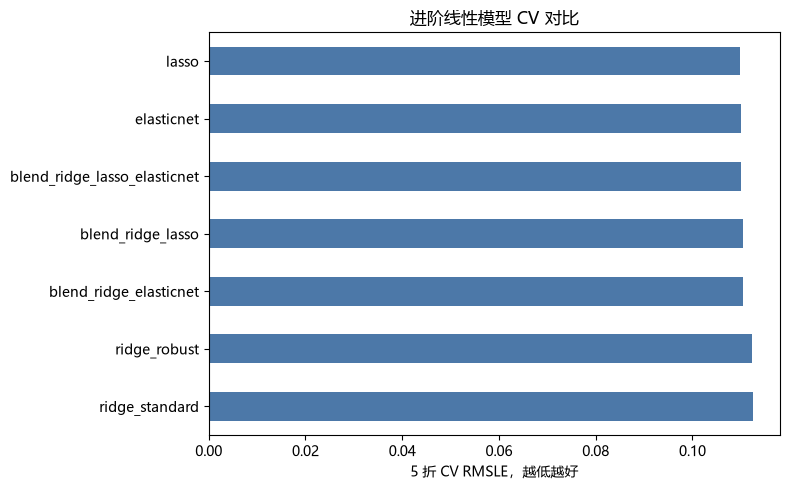

In [8]:
ax = score_table.sort_values("CV_RMSLE", ascending=False).plot(
    kind="barh",
    x="方案",
    y="CV_RMSLE",
    legend=False,
    figsize=(8, 5),
    color="#4C78A8",
)
ax.set_title("进阶线性模型 CV 对比")
ax.set_xlabel("5 折 CV RMSLE，越低越好")
ax.set_ylabel("")
plt.tight_layout()

## 7. 生成提交文件

按本地 CV 选择最优方案生成提交文件。提交后仍以 Kaggle 公榜结果为准。

In [9]:
best_name = score_table.iloc[0]["方案"]

if best_name in models:
    final_model = clone(models[best_name])
    final_model.fit(X_log, y)
    final_predictions = final_model.predict(X_test_log)
else:
    final_predictions_list = []
    for model in ensemble_candidates[best_name].values():
        fitted_model = clone(model)
        fitted_model.fit(X_log, y)
        final_predictions_list.append(fitted_model.predict(X_test_log))
    final_predictions = np.mean(final_predictions_list, axis=0)

final_predictions = np.maximum(final_predictions, 0)
submission = pd.DataFrame({"Id": test_ids, "SalePrice": final_predictions})

SUBMISSION_DIR.mkdir(exist_ok=True)
submission_path = SUBMISSION_DIR / "04_submission_advanced_linear.csv"
submission.to_csv(submission_path, index=False)

best_name, submission_path, submission.head(), submission["SalePrice"].describe()

('lasso',
 WindowsPath('C:/Users/84740/house-prices-advanced-regression/submissions/04_submission_advanced_linear.csv'),
      Id      SalePrice
 0  1461  119982.559191
 1  1462  153846.591528
 2  1463  182532.912879
 3  1464  200172.715175
 4  1465  195614.309458,
 count    1.459000e+03
 mean     1.789824e+05
 std      7.950065e+04
 min      4.394139e+04
 25%      1.267443e+05
 50%      1.582326e+05
 75%      2.110612e+05
 max      1.003536e+06
 Name: SalePrice, dtype: float64)

## 8. 提交命令

```powershell
kaggle competitions submit -c house-prices-advanced-regression-techniques -f submissions/04_submission_advanced_linear.csv -m "advanced linear regularized model"
```

提交后，把公榜分数记录到 `notebooks/99_submission_score_analysis.md`。